In [1]:
# enables automatic library refreshes when importing changes to a library
%load_ext autoreload
%autoreload 2

In [6]:
cd ../

/work/nvme/bhvr/fatimasyed7/Stars_VAE


In [2]:

import sys
import socket
import importlib
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.config import profile_features, split_feature, num_profile_points, processed_data_path, raw_data_path
from src.preprocessing import rdp_preprocess, fit_preprocess_scalers

In [4]:
# loads raw data into a dataframe to be processed

sim = np.load(raw_data_path, allow_pickle=True)

df = pd.DataFrame(sim)

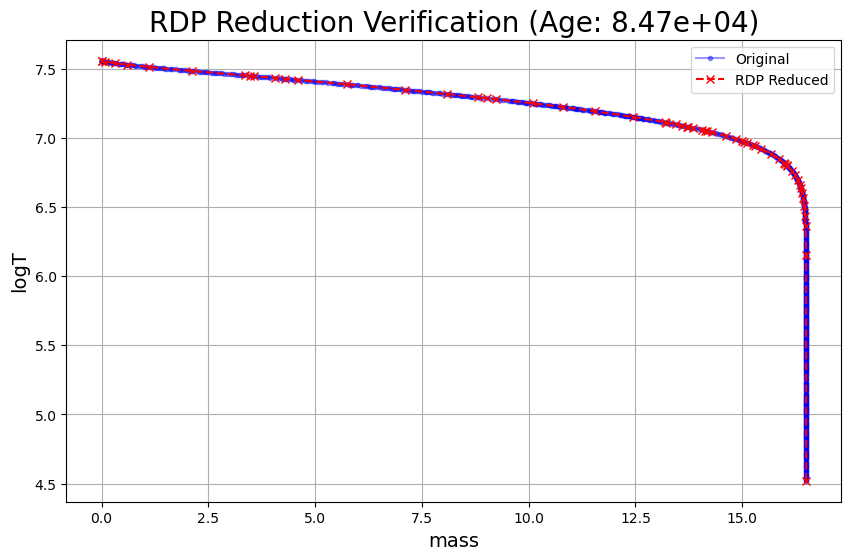

In [5]:
'''Skip this step if data is already RDP processed'''
# runs RDP algorithm on raw data and saves it in data/processed
processed_df = rdp_preprocess(df, num_profile_points)

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
np.save(processed_data_path, processed_df)

# used to visualize which points were selected by rdp algorithm
from src.utils import varify_rdp

varify_rdp(df, processed_df)

In [6]:
# Reconstruct DataFrame from the RDP NumPy array output
processed_df = np.load(processed_data_path, allow_pickle=True)

column_headers = profile_features + [split_feature]
processed_dataframe = pd.DataFrame(processed_df, columns=column_headers)

# Normalize data
df_scaled, scalers = fit_preprocess_scalers(
    processed_dataframe,
    normalize=True,
    standardize=False,
)

arr = df_scaled.to_numpy()

In [7]:
from src.train import train_model
import src.config

metrics = train_model(arr)

Training on device: cpu
Model: VAE(
  (encoder): Sequential(
    (0): Linear(in_features=120, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
  )
  (fc_mu): Linear(in_features=128, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyR

RuntimeError: mat1 and mat2 shapes cannot be multiplied (128x2 and 120x512)